# This is a sample Jupyter Notebook

Below is an implementation of the project.

In [57]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import time

In [58]:
# load
train_path = ("data/mitbih_train.csv")
test_path = ("data/mitbih_test.csv")

train = pd.read_csv(train_path, header=None)
for i in range(train.shape[1]):
    train = train.rename(columns={train.columns[i]: str(i)})
train = train.rename(columns={train.columns[-1]: "label"})

test = pd.read_csv(test_path, header=None)
for i in range(test.shape[1]):
    test = test.rename(columns={test.columns[i]: str(i)})
test = test.rename(columns={test.columns[-1]: "label"})

# distribution
x_train = train.drop("label", axis=1)
y_train = train["label"]

x_test = test.drop("label", axis=1)
y_test = test["label"]

print(train.head())

print("train shape:", train.shape)
print("test shape :", test.shape)

          0         1         2         3         4         5         6  \
0  0.977941  0.926471  0.681373  0.245098  0.154412  0.191176  0.151961   
1  0.960114  0.863248  0.461538  0.196581  0.094017  0.125356  0.099715   
2  1.000000  0.659459  0.186486  0.070270  0.070270  0.059459  0.056757   
3  0.925414  0.665746  0.541436  0.276243  0.196133  0.077348  0.071823   
4  0.967136  1.000000  0.830986  0.586854  0.356808  0.248826  0.145540   

          7         8         9  ...  178  179  180  181  182  183  184  185  \
0  0.085784  0.058824  0.049020  ...  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0   
1  0.088319  0.074074  0.082621  ...  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0   
2  0.043243  0.054054  0.045946  ...  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0   
3  0.060773  0.066298  0.058011  ...  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0   
4  0.089202  0.117371  0.150235  ...  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0   

   186  label  
0  0.0    0.0  
1  0.0    0.0  
2  0.0    0.0  
3  0

In [59]:
x_train.info()

procent_null = 100 * x_train.isnull().sum().sum() / x_train.size
print(f"Procent brakujacych danych: {procent_null:.2f}%")

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 87554 entries, 0 to 87553
Columns: 187 entries, 0 to 186
dtypes: float64(187)
memory usage: 124.9 MB
Procent brakujacych danych: 0.00%


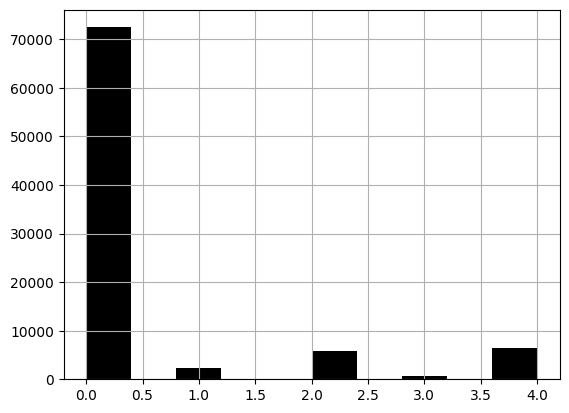

In [60]:
y_train.hist(bins = 10, color='black')
plt.show()

In [61]:
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

proc_pipeline = Pipeline(steps=[
    ('std_scaler', StandardScaler()),
])

column_transformer = ColumnTransformer([
    ('num', proc_pipeline, x_train.columns),
])

preprocessor = Pipeline(steps=[
    ('column_transformer', column_transformer),
])

x_ready = preprocessor.fit_transform(x_train)
print(x_ready)

[[ 0.36354765  0.75879683  1.13240614 ... -0.09259618 -0.08959366
  -0.08793965]
 [ 0.28954748  0.47376846  0.16526879 ... -0.09259618 -0.08959366
  -0.08793965]
 [ 0.45511319 -0.44497542 -1.04479413 ... -0.09259618 -0.08959366
  -0.08793965]
 ...
 [ 0.06543057 -0.60263006  0.75645932 ... -0.09259618 -0.08959366
  -0.08793965]
 [-0.13337832 -0.50759535  1.85477435 ... -0.09259618 -0.08959366
  -0.08793965]
 [ 0.04626936  0.39549766  1.65735418 ... -0.09259618 -0.08959366
  -0.08793965]]


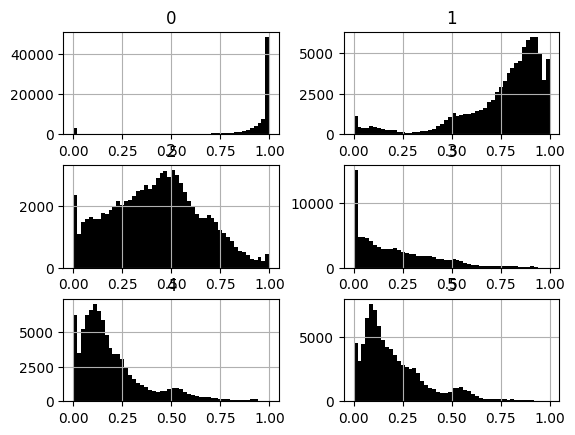

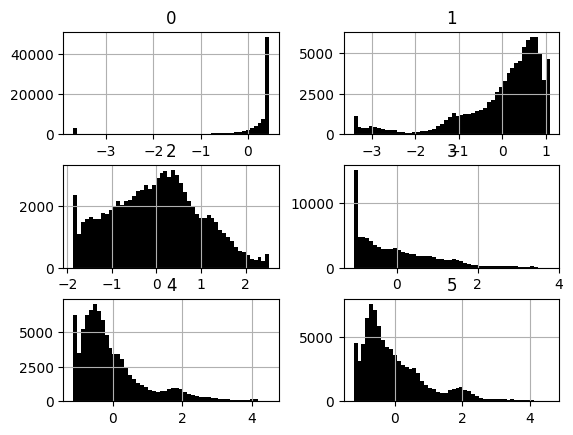

In [62]:
col = x_train.columns[:6]

x_train[col].hist(bins = 50, color='black')
plt.show()

x_ready_df = pd.DataFrame(x_ready, columns=x_train.columns)
x_ready_df[col].hist(bins = 50, color='black')
plt.show()

In [63]:
print("Before:")
print(x_train.iloc[:, :3].mean(), x_train.iloc[:, :3].std())

print("After:")
print(x_ready_df.iloc[:, :3].mean(), x_ready_df.iloc[:, :3].std())

Before:
0    0.890360
1    0.758160
2    0.423972
dtype: float64 0    0.240909
1    0.221813
2    0.227305
dtype: float64
After:
0   -1.142660e-16
1    1.662050e-16
2    4.155126e-17
dtype: float64 0    1.000006
1    1.000006
2    1.000006
dtype: float64


In [64]:
from sklearn.metrics import mean_squared_error, f1_score
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression, SGDClassifier
from sklearn.ensemble import RandomForestClassifier

log_reg = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('model', LogisticRegression(
        max_iter=1000, # wydawalo warning na 100, ze nie znalazlo plateau
    )),
])

sgd_class = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('model', SGDClassifier()),
])

forest_class = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('model', RandomForestClassifier()),
])

start_time = time.time()
log_reg.fit(x_train, y_train)
log_pred = log_reg.predict(x_train)
end_time = time.time()
print("Czas log_reg: ", end_time - start_time)

start_time = time.time()
sgd_class.fit(x_train, y_train)
sgd_pred = sgd_class.predict(x_train)
end_time = time.time()
print("Czas sgd_class: ", end_time - start_time)

start_time = time.time()
forest_class.fit(x_train, y_train)
forest_pred = forest_class.predict(x_train)
end_time = time.time()
print("Czas forest_class: ", end_time - start_time)

print("RMSE dla LogisticRegression: ", np.sqrt(mean_squared_error(y_train, log_pred)))
print("RMSE dla SGDClassifier: ", np.sqrt(mean_squared_error(y_train, sgd_pred)))
print("RMSE dla RandomForestClassifier: ", np.sqrt(mean_squared_error(y_train, forest_pred)))

Czas log_reg:  26.75354790687561
Czas sgd_class:  24.751656532287598
Czas forest_class:  127.42998886108398
RMSE dla LogisticRegression:  0.6472392217944736
RMSE dla SGDClassifier:  0.6637917620701482
RMSE dla RandomForestClassifier:  0.0


Number of normal:  72471
Number of supraventricular ectopic beat:  2223
Number of ventricular ectopic beat:  5788
Number of fusion beat:  641
Number of nieokreślone / paced beat:  6431

Dla LogisticRegression
Confusion Matrix:



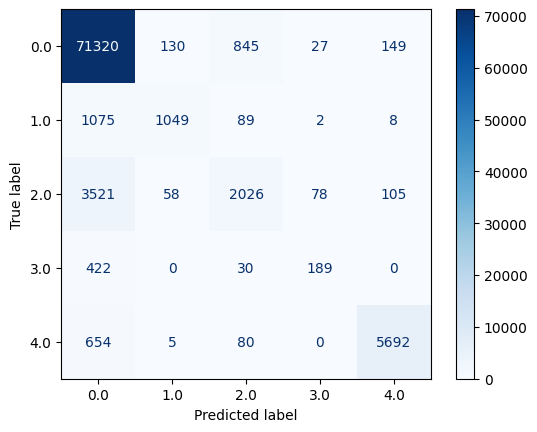

makro-F1 score:  0.6679728983881918
Dla SGDClassifier
Confusion Matrix:



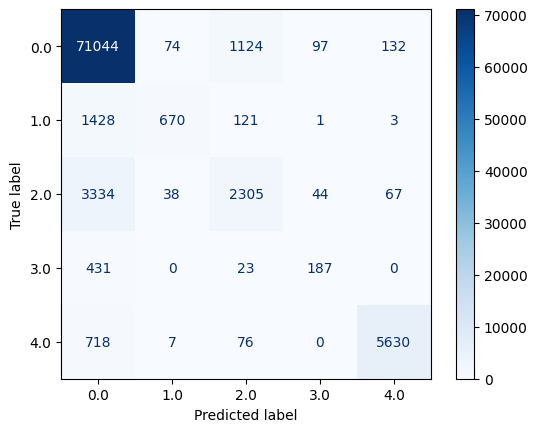

makro-F1 score:  0.6376116316646592
Dla RandomForestClassifier
Confusion Matrix:



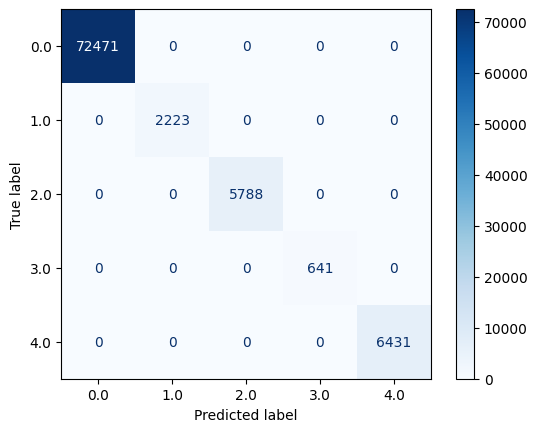

makro-F1 score:  1.0
Dla RandomForestClassifier na testowym
Confusion Matrix:



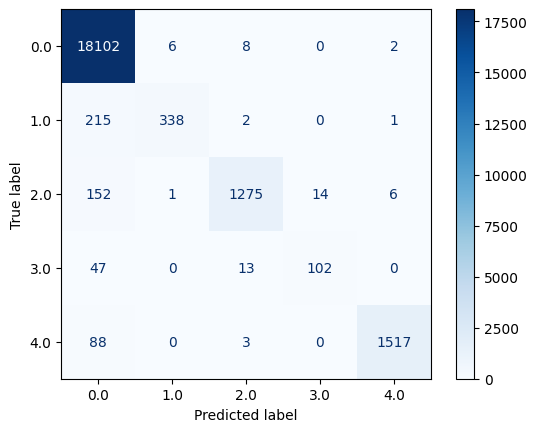

makro-F1 score:  0.8731372737923682


In [67]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, f1_score
classes = np.unique(y_train)

print("Number of normal: ", (y_train == 0).sum())
print("Number of supraventricular ectopic beat: ", (y_train == 1).sum())
print("Number of ventricular ectopic beat: ", (y_train == 2).sum())
print("Number of fusion beat: ", (y_train == 3).sum())
print("Number of nieokreślone / paced beat: ", (y_train == 4).sum())

print("\nDla LogisticRegression")
print("Confusion Matrix:\n")
log_reg_cm = confusion_matrix(y_train, log_pred)
disp1 = ConfusionMatrixDisplay(confusion_matrix=log_reg_cm, display_labels=classes)
disp1.plot(cmap='Blues')
plt.show()
print("makro-F1 score: ", f1_score(y_train, log_pred, average='macro'))

print("Dla SGDClassifier")
print("Confusion Matrix:\n")
sgd_cm = confusion_matrix(y_train, sgd_pred)
disp2 = ConfusionMatrixDisplay(confusion_matrix=sgd_cm, display_labels=classes)
disp2.plot(cmap='Blues')
plt.show()
print("makro-F1 score: ", f1_score(y_train, sgd_pred, average='macro'))

print("Dla RandomForestClassifier")
print("Confusion Matrix:\n")
forest_cm = confusion_matrix(y_train, forest_pred)
disp3 = ConfusionMatrixDisplay(confusion_matrix=forest_cm, display_labels=classes)
disp3.plot(cmap='Blues')
plt.show()
print("makro-F1 score: ", f1_score(y_train, forest_pred, average='macro'))

forest_pred_test  = forest_class.predict(x_test)
print("Dla RandomForestClassifier na testowym") # dla sprawdzenia
print("Confusion Matrix:\n")
forest_cm_2 = confusion_matrix(y_test, forest_pred_test)
disp4 = ConfusionMatrixDisplay(confusion_matrix=forest_cm_2, display_labels=classes)
disp4.plot(cmap='Blues')
plt.show()
print("makro-F1 score: ", f1_score(y_test, forest_pred_test, average='macro'))